In [2]:
import anndata
import networkx as nx
import numpy as np
import scgenome.plotting as pl

from cellmates.utils.math_utils import compute_cn_changes
from cellmates.utils.tree_utils import f1_score_clades, relabel_name_to_int, newick_to_nx, convert_networkx_to_dendropy, \
    nxtree_to_newick, normalized_rf_distance

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Analysis for SPECTRUM OV-125 dataset


## OV-125

In [3]:
path = "/home/vittorio.zampinetti/cellmates_res/real_data/SPECTRUM-OV-125_cm_out/processed_adata.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 32 × 598
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'index_i7', 'fastqscreen_total_reads', 'paired_mapped_reads', 'fastqscreen_mouse', 'index_sequence', 'coverage_breadth', 'total_duplicate_reads', 'library_id', 'overlap_with_all_filters', 'estimated_library_size', 'column', 'coverage_depth', 'unpaired_mapped_reads', 'percent_duplicate_reads', 'condition', 'expected', 'sample_type', 'is_control', 'median_insert_size', 'standard_deviation_insert_size', 'fastqscreen_salmon_multihit', 'img_col', 'total_mapped_reads', 'fastq

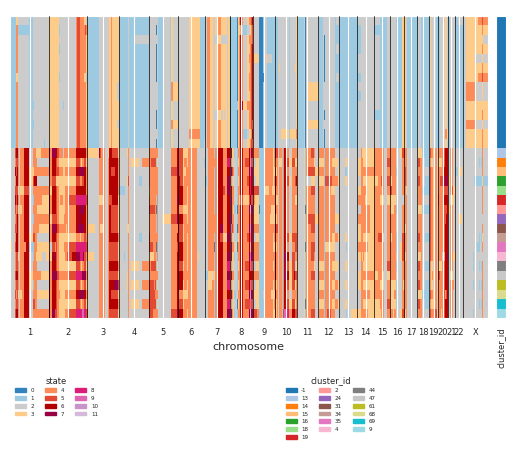

In [4]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

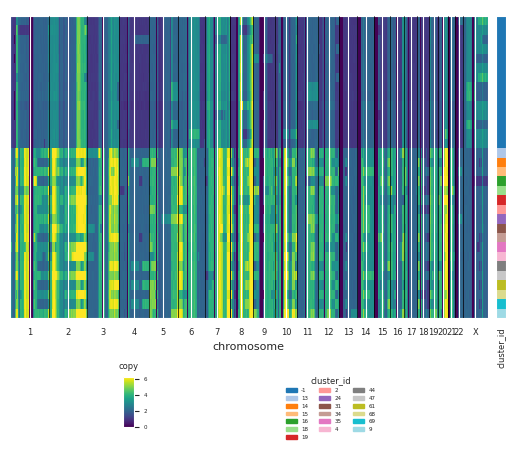

In [5]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

#### KMeans clustering

Keeping bins without nans: 598 / 598
Running KMeans with K=4
  Silhouette score: 0.4794
Running KMeans with K=5
  Silhouette score: 0.4804
Running KMeans with K=6
  Silhouette score: 0.4691
Running KMeans with K=7
  Silhouette score: 0.2336
Running KMeans with K=8
  Silhouette score: 0.2480
Running KMeans with K=9
  Silhouette score: 0.2293

Best K: 5 with silhouette score: 0.4804


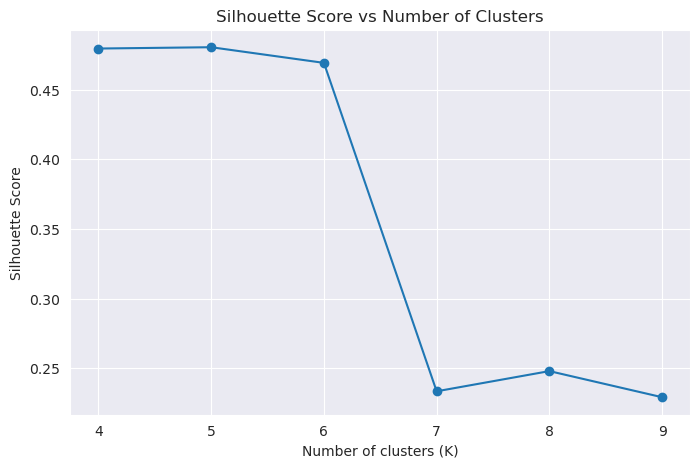

In [6]:
rerun_kmeans = True
if rerun_kmeans:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    kval = [4, 5, 6, 7, 8, 9]
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    print(f"Keeping bins without nans: {np.sum(valid_bins)} / {adata.n_vars}")
    cn_mat = adata[:, valid_bins].layers['state']

    silhouette_scores = []
    best_k = None
    best_score = -1
    best_labels = None

    for k in kval:
        print(f"Running KMeans with K={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(cn_mat)

        # Calculate silhouette score
        score = silhouette_score(cn_mat, labels)
        silhouette_scores.append(score)
        print(f"  Silhouette score: {score:.4f}")

        # Track best k
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nBest K: {best_k} with silhouette score: {best_score:.4f}")

    # Optional: visualize results
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.plot(kval, silhouette_scores, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True)
    plt.show()

    # Store best clustering in adata
    adata.obs[f'kmeans_k{best_k}'] = best_labels
else:
    print("Best K: 9 with silhouette score: 0.4477")

#### Leiden clustering


Running Leiden with resolution=1.0
  Clusters: 2
  Silhouette: 0.7002
  Davies-Bouldin: 0.4161 (lower is better)
  Calinski-Harabasz: 133.81 (higher is better)

Running Leiden with resolution=1.5
  Clusters: 3
  Silhouette: 0.2909
  Davies-Bouldin: 0.9517 (lower is better)
  Calinski-Harabasz: 67.16 (higher is better)

Running Leiden with resolution=2.0
  Clusters: 11
  Silhouette: 0.3613
  Davies-Bouldin: 0.7914 (lower is better)
  Calinski-Harabasz: 27.34 (higher is better)

=== Summary ===
   resolution  n_clusters  silhouette  davies_bouldin  calinski_harabasz
0         1.0           2    0.700209        0.416083         133.809094
1         1.5           3    0.290883        0.951728          67.162589
2         2.0          11    0.361330        0.791356          27.337986

Best by Silhouette: resolution=1.0, score=0.7002
Best by Davies-Bouldin: resolution=1.0, score=0.4161
Best by Calinski-Harabasz: resolution=1.0, score=133.81


/tmp/ipykernel_887181/1925022367.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')


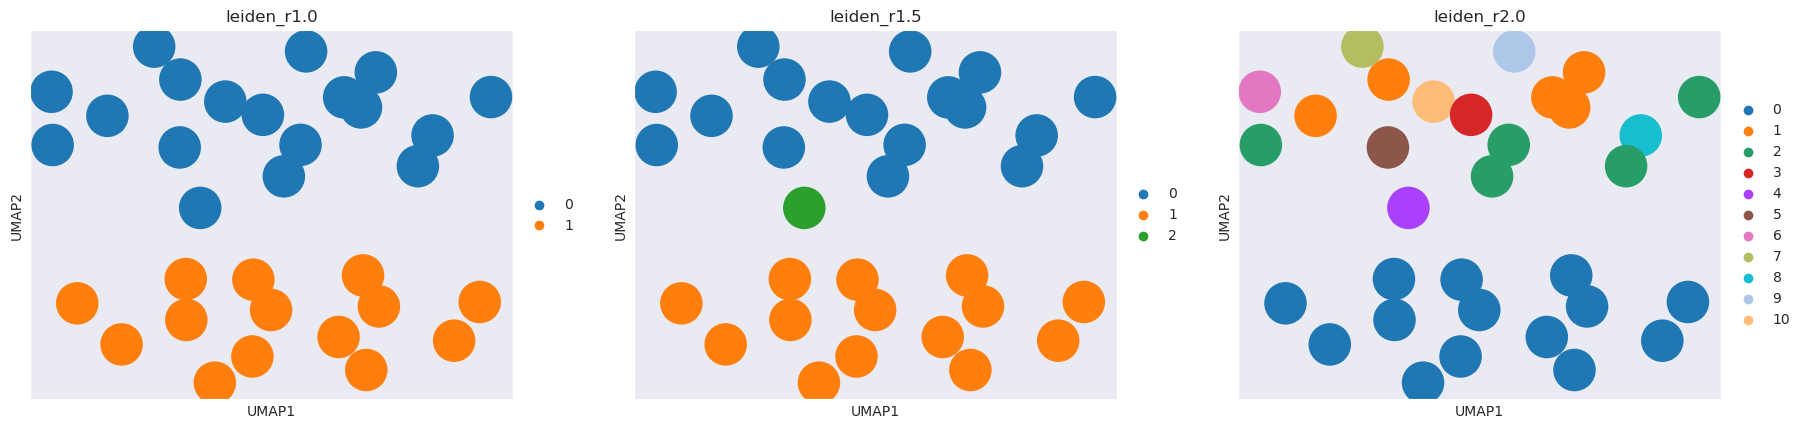

In [7]:
rerun_leiden = True
if rerun_leiden:
    import scanpy as sc
    import numpy as np

    # 1. First, compute neighbors on your CN state data (not the default adata.X)
    # Temporarily store filtered CN data in adata.X for neighbor computation
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    adata_filt = adata[:, valid_bins].copy()
    adata_filt.X = adata_filt.layers['state']

    # 2. Compute neighbors on the CN data
    sc.pp.neighbors(adata_filt, n_neighbors=15, n_pcs=0, metric='manhattan')  # n_pcs=0 means use raw data, no PCA

    # 3. Try different resolutions and evaluate with multiple metrics
    resolutions = [1.0, 1.5, 2.0]
    results = []

    for res in resolutions:
        print(f"\nRunning Leiden with resolution={res}")
        sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')

        labels = adata_filt.obs[f'leiden_r{res}'].astype('category').cat.codes.values
        n_clusters = len(np.unique(labels))

        # Calculate multiple metrics
        from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

        sil_score = silhouette_score(adata_filt.X, labels)
        db_score = davies_bouldin_score(adata_filt.X, labels)  # Lower is better
        ch_score = calinski_harabasz_score(adata_filt.X, labels)  # Higher is better

        adata.obs[f'leiden_r{res}'] = labels

        results.append({
            'resolution': res,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score
        })

        print(f"  Clusters: {n_clusters}")
        print(f"  Silhouette: {sil_score:.4f}")
        print(f"  Davies-Bouldin: {db_score:.4f} (lower is better)")
        print(f"  Calinski-Harabasz: {ch_score:.2f} (higher is better)")


    # 5. Summary and best resolution selection
    import pandas as pd
    results_df = pd.DataFrame(results)
    print("\n=== Summary ===")
    print(results_df)

    # Best by different metrics
    best_sil = results_df.loc[results_df['silhouette'].idxmax()]
    best_db = results_df.loc[results_df['davies_bouldin'].idxmin()]
    best_ch = results_df.loc[results_df['calinski_harabasz'].idxmax()]

    print(f"\nBest by Silhouette: resolution={best_sil['resolution']}, score={best_sil['silhouette']:.4f}")
    print(f"Best by Davies-Bouldin: resolution={best_db['resolution']}, score={best_db['davies_bouldin']:.4f}")
    print(f"Best by Calinski-Harabasz: resolution={best_ch['resolution']}, score={best_ch['calinski_harabasz']:.2f}")
    # 6. Optional: Visualize if you have UMAP/PCA
    sc.tl.umap(adata_filt)
    sc.pl.umap(adata_filt, color=[f'leiden_r{r}' for r in [1.0, 1.5, 2.0]])#%% md
else:
    print("Not run yet")

#### Conclusions
Both clustering methods find very poor clustering, therefore we can conclude that this dataset, despite the motivation, is just trash (it doesn't suit our purposes)

### Cellmates tree

In [8]:
import os
import io
from Bio import Phylo

cm_out_dir = "/home/vittorio.zampinetti/cellmates_res/real_data/SPECTRUM-OV-125_cm_out"
cell_names = open(os.path.join(cm_out_dir, "cell_names.txt")).read().splitlines()
tree_nwk = open(os.path.join(cm_out_dir, "tree.nwk")).read().strip()
nx_tree = newick_to_nx(tree_nwk)
bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")
# bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree)), "newick")
print(tree_nwk)
print(len(cell_names), adata[cell_names].n_obs)
print(cell_names, adata[cell_names].obs.index.tolist())

((SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R15-C31:0.001967716994053279,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R27-C20:0.0015678523865522926,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R14-C27:0.002629576573485647,((((SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R27-C15:1.2490009027033023e-16,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R22-C14:1.110223024625157e-16,SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R30-C20:1.8041124150158806e-16)ancestor28:0.00032900693990028235)ancestor23:0.0009869702323288057,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R17-C23:0.0020595934478905764,SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R28-C17:0.0013058937038628769)ancestor24:0.0003525156053597704)ancestor17:0.0002306657475890008,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R31-C12:0.002591601701684561,SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R32-C29:0.0027164671406035863)ancestor18:0.0002164404347966345)ancestor12:3.756908024279276e-05,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R16-C15:0.0008081056996999382,(SPECTRUM-OV-125_S1_LEFT_OVARY-128699A-R18

In [10]:
# add cellmates cn
def get_cellmates_cn_matrix(pred_file="predicted_copy_numbers.npz", par_dir=None):
    if par_dir is not None:
        cm_out_dir = par_dir
    prediction = np.load(os.path.join(cm_out_dir, pred_file))
    cn_mat = prediction['data']
    labels = prediction['labels']  # [cell0, cell1, ..., ancestor3, ..., root]
    cn_mat.shape
    map_cells = {l: i for i, l in enumerate(labels)}
    cell_cn_mat = cn_mat[[map_cells[c] for c in cell_names]]
    return cell_cn_mat


In [9]:
import pickle
diags = None
with open(cm_out_dir + "/em_diagnostics.pkl", "rb") as f:
    diags = pickle.load(f)
print(diags[(0, 1)])

tau_array = np.concatenate([diags[x]['psis'][-1][[1,3]] for x in diags.keys()])
print(f"tau stats: {tau_array.shape}, mean: {np.mean(tau_array):.4f} +- {np.std(tau_array):.4f}")

# for c, lab in enumerate(cell_names):


{'loglikelihoods': [None, -1111.9585892236325, -894.5769270383284, -774.4166455681393, -721.9362767404609, -715.3628176995281, -715.1142808164599], 'thetas': [array([0.00790768, 0.01830938, 0.02939356]), array([0.00599177, 0.009143  , 0.02122693]), array([0.00849289, 0.01112584, 0.02217309]), array([0.01026497, 0.01418351, 0.02383053]), array([0.01112607, 0.01603719, 0.02488687]), array([0.01134749, 0.01675135, 0.02559276]), array([0.01132298, 0.01697331, 0.02606023])], 'psis': [array([1. , 3.6, 1. , 3.6]), array([0.99138123, 9.17288816, 1.00791834, 6.26222551]), array([ 0.98721213, 18.94012563,  1.01113449,  8.68568941]), array([ 0.98641577, 32.59188348,  1.0134382 , 10.30823325]), array([ 0.98492116, 38.98130357,  1.01419966, 11.32417232]), array([ 0.98471961, 40.4473026 ,  1.01456438, 11.86247994]), array([ 0.98481248, 40.6974977 ,  1.01475573, 12.13417696])]}
tau stats: (992,), mean: 29.1230 +- 11.9872


In [13]:
adata.layers['cellmates-cn'] = get_cellmates_cn_matrix(par_dir=cm_out_dir)
# adata.layers['cellmates-cn-jitter'] = get_cellmates_cn_matrix("predicted_copy_numbers_cn.npz")

In [27]:
adata.shape

(32, 598)

In [14]:
# clustering_lab = 'leiden_r0.5'
clustering_lab = 'kmeans_k5'
# clustering_lab = 'cluster_id'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


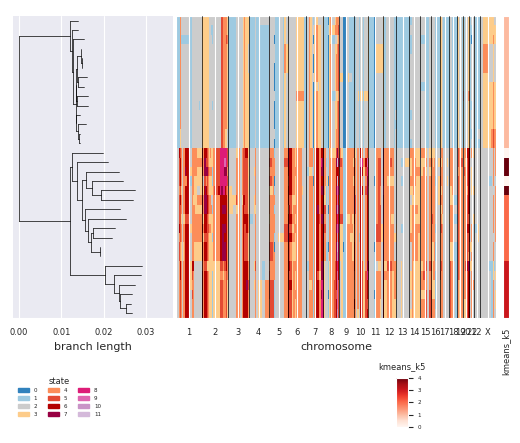

In [15]:
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab])
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, annotation_fields=[clustering_lab])
# log-scale branches maybe

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


<bound method Figure.show of <Figure size 2400x1800 with 8 Axes>>

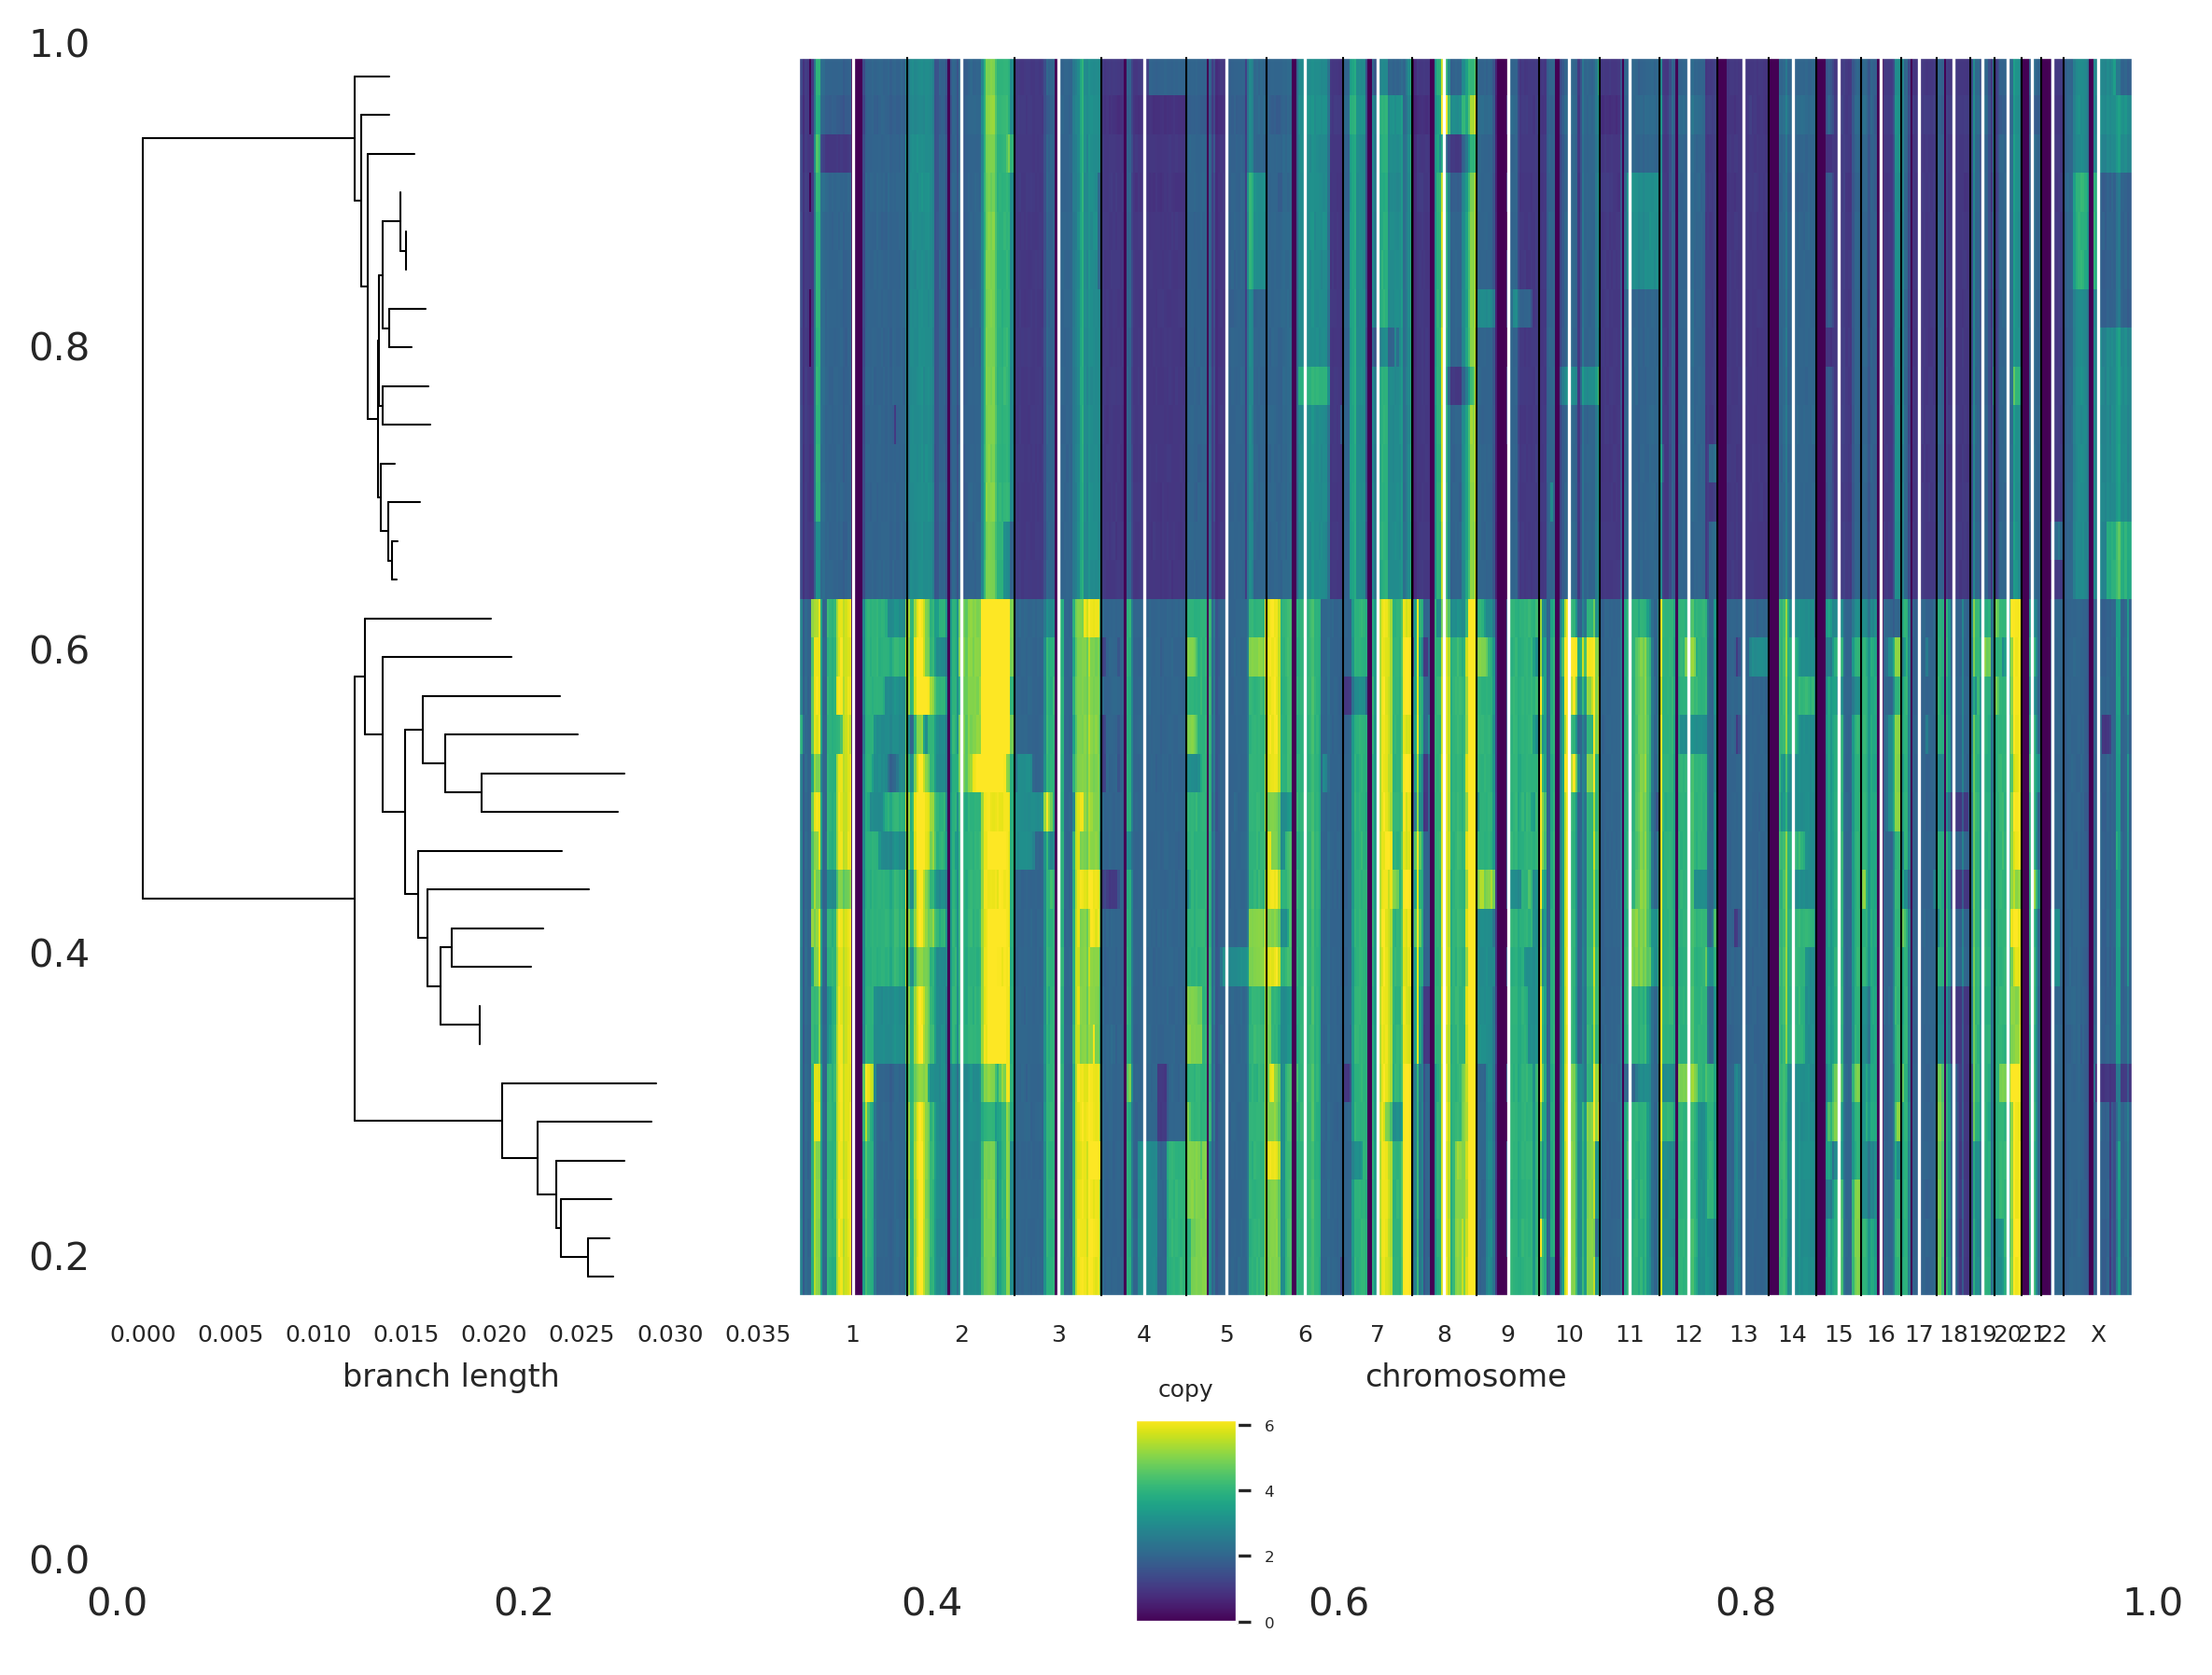

In [26]:
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab, 'is_s_phase'])
fig, ax = plt.subplots(figsize=(8, 6), dpi=300, )
fig.tight_layout()
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cellmates-cn', tree=bio_tree, fig=fig,
#                                # annotation_fields=[clustering_lab]
#                                )
vmax = np.nanpercentile(adata[cell_names].layers['copy'], 98)
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='copy', tree=bio_tree, fig=fig, raw=True, vmax=vmax
                               # annotation_fields=[clustering_lab]
                               )
for a in fig.axes:
    a.set_facecolor('white')
    # a.set(xticks=[], yticks=[])

g['fig'].show

# log-scale branches maybe

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


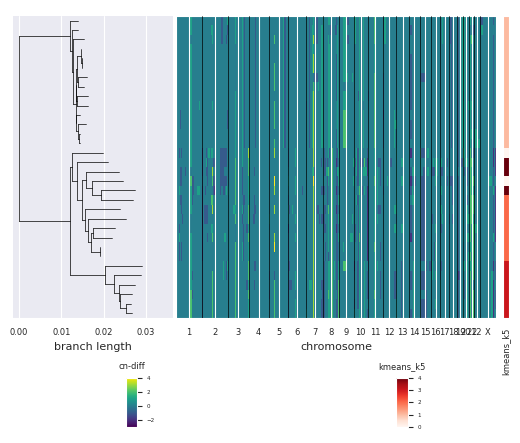

In [17]:
adata.layers['cn-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['state'], a_min=0, a_max=8)
# adata.layers['cn-reads-diff'] = adata.layers['cellmates-cn'] - np.clip(adata.layers['copy'], a_min=0, a_max=8)
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)
# g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='cn-reads-diff', tree=bio_tree, annotation_fields=[clustering_lab], raw=True)

In [30]:
cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn'] - adata.layers['state']))
cm_cn_mse = np.nanmean(np.abs(adata.layers['cellmates-cn'] - adata.layers['state'])**2)
# cm_cn_mad = np.nanmean(np.abs(adata.layers['cellmates-cn-jitter'] - adata.layers['state']))
print(f"CN MAD against original (HMMcopy) {cm_cn_mad}")
print(f"CN MSE against original (HMMcopy) {cm_cn_mse}")


CN MAD against original (HMMcopy) 0.16262541806020067
CN MSE against original (HMMcopy) 0.23076923076923078


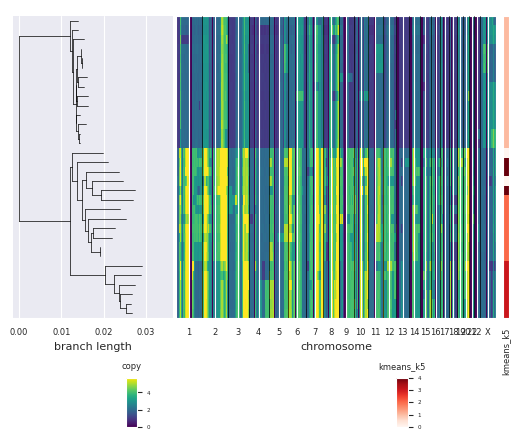

In [16]:
perc_98 = np.nanquantile(adata.layers['copy'], .95)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [17]:
nx_tree_int = relabel_name_to_int(nx_tree, cell_names)
dpy_tree = convert_networkx_to_dendropy(nx_tree_int, edge_length='weight')
f1_score = f1_score_clades(dpy_tree, adata[cell_names].obs[clustering_lab])

In [18]:
f1_score

0.7789010989010988

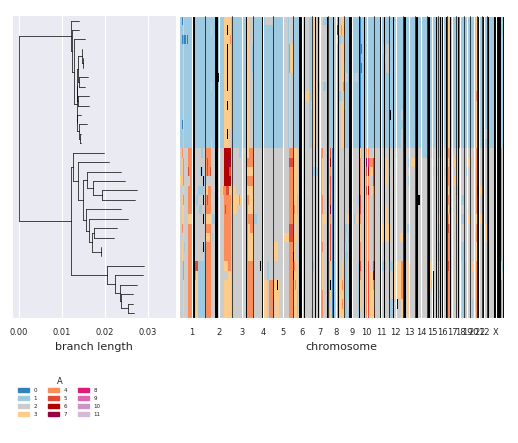

In [81]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='A', tree=bio_tree)

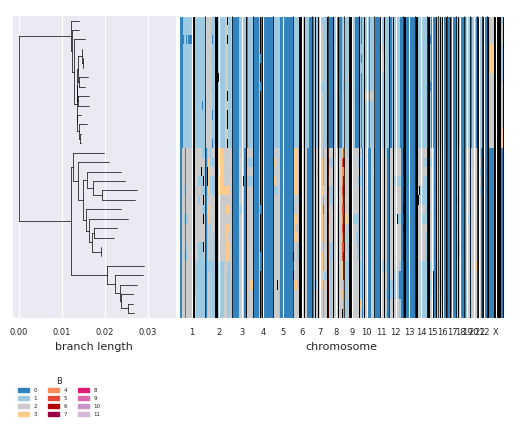

In [82]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='B', tree=bio_tree)

In [62]:
as_adata = anndata.read_h5ad(cm_out_dir+"_phased/processed_adata.h5ad")
as_adata

AnnData object with n_obs × n_vars = 32 × 1196
    obs: 'multiplier', 'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness', 'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy', 'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin', 'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin', 'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness', 'mean_state_mads', 'mean_state_vars', 'mad_neutral_state', 'breakpoints', 'mean_copy', 'state_mode', 'log_likelihood', 'true_multiplier', 'index_i7', 'fastqscreen_total_reads', 'paired_mapped_reads', 'fastqscreen_mouse', 'index_sequence', 'coverage_breadth', 'total_duplicate_reads', 'library_id', 'overlap_with_all_filters', 'estimated_library_size', 'column', 'coverage_depth', 'unpaired_mapped_reads', 'percent_duplicate_reads', 'condition', 'expected', 'sample_type', 'is_control', 'median_insert_size', 'standard_deviation_insert_size', 'fastqscreen_salmon_multihit', 'img_col', 'total_mapped_reads', 'fast

(np.float64(-0.5), np.float64(1195.5), np.float64(31.5), np.float64(-0.5))

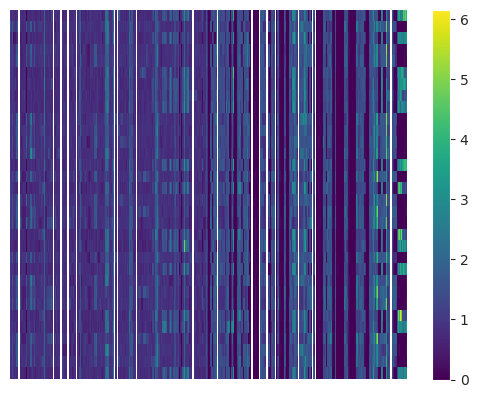

In [63]:
import matplotlib.pyplot as plt

# cmap = matplotlib.cm.get_cmap('viridis')
fig, ax = plt.subplots()
perc_98 = np.nanpercentile(adata.layers['copy'], 98)
im = ax.imshow(as_adata.layers['copy'], cmap='viridis', aspect='auto', interpolation='none', vmax=perc_98)
ax.set_xlabel('bins', fontsize=8)
ax.set_ylabel('cells', fontsize=8)
fig.colorbar(im)
ax.axis('off')

## Allele specific Cellmates

In [94]:
as_cn = get_cellmates_cn_matrix(pred_file="predicted_copy_numbers.npz", par_dir=cm_out_dir+'_phased')
as_cn.shape

(32, 1196)

In [95]:
adata.layers['cellmates-cnA'] = as_cn[:, :adata.n_vars]
adata.layers['cellmates-cnB'] = as_cn[:, adata.n_vars:]

In [96]:
as_tree_nwk = open(os.path.join(cm_out_dir+"_phased", "tree.nwk")).read().strip()
as_nx_tree = newick_to_nx(tree_nwk)
as_bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")

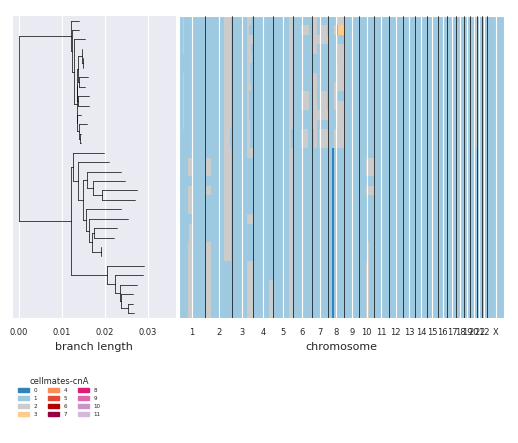

In [97]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='cellmates-cnA', tree=bio_tree)

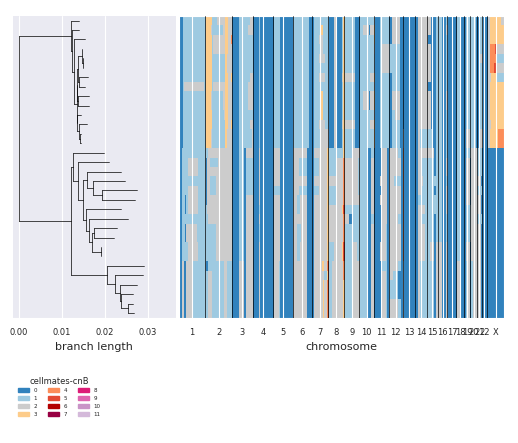

In [98]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='cellmates-cnB', tree=bio_tree)

In [99]:
#adata.write_h5ad("/home/vittorio.zampinetti/cellmates_res/real_data/SPECTRUM-OV-125_cm_out_phased_nowgd/processed_adata.h5ad")

In [100]:
import pickle
diags = None
with open(cm_out_dir+"_phased" + "/em_diagnostics.pkl", "rb") as f:
    diags = pickle.load(f)
print(diags[(0, 1)])

tau_array = np.concatenate([diags[x]['psis'][-1][[1,3]] for x in diags.keys()])
print(f"tau stats: {tau_array.shape}, mean: {np.mean(tau_array):.4f} +- {np.std(tau_array):.4f}")

mu_array = np.concatenate([diags[x]['psis'][-1][[0,2]] for x in diags.keys()])
print(f"mu stats: {mu_array.shape}, mean: {np.mean(mu_array):.4f} +- {np.std(mu_array):.4f}")



{'loglikelihoods': [None, -1751.2377201284012, -1113.9167600157666, -749.9778550321943, -445.3718087382918, -284.3566338733021, -232.21433611258516, -225.3082612868096, -225.30979394124327, -225.47194054726882, -225.53261299640783, -225.55367244694932, -225.55949648829932, -225.5622424227595, -225.56343611641142, -225.56198030373676], 'thetas': [array([0.01382892, 0.02350108, 0.03077029]), array([0.00651117, 0.00819938, 0.00811798]), array([0.00884009, 0.008079  , 0.00778658]), array([0.01100951, 0.0091825 , 0.01007896]), array([0.01109501, 0.01134254, 0.01259596]), array([0.01117407, 0.01378222, 0.01349889]), array([0.01130813, 0.01570163, 0.01383623]), array([0.01133419, 0.0164571 , 0.01384794]), array([0.01132282, 0.0167146 , 0.01383886]), array([0.01131132, 0.01679636, 0.01383455]), array([0.01130566, 0.01682273, 0.01383388]), array([0.01130272, 0.01683048, 0.0138332 ]), array([0.01130186, 0.01683342, 0.01383353]), array([0.01130156, 0.01683472, 0.01383365]), array([0.01130083, 0.0

In [ ]:
print(np.nanmean(np.abs(as_adata.layers['copy']/2 - as_adata.layers['state'])))
print(np.nanmean(np.abs(as_adata.layers['copy'] - as_adata.layers['state'])))
print(np.nanmean(np.abs(2 * as_adata.layers['copy'] - as_adata.layers['state'])))

k### MEDICC2

In [91]:
medicc_adata = anndata.read_h5ad(os.path.join(cm_out_dir, "medicc2", "OV125_medicc2_output.h5ad"))
medicc_adata_cells = medicc_adata[cell_names].copy()
medicc_adata_cells.obs[clustering_lab] = adata[medicc_adata_cells.obs_names].obs[clustering_lab]
medicc_adata_cells.layers['copy'] = adata[medicc_adata_cells.obs_names, medicc_adata_cells.var_names].layers['copy']
medicc_adata_cells

In [92]:
# add cn to adata
import pandas as pd
cn_df = pd.read_csv(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_input_final_final_cn_profiles.tsv"), delimiter='\t')
cn_tab = cn_df.pivot(index='sample_id', columns=['chrom', 'start', 'end'], values='total_cn')
assert np.all([c in cn_tab.index for c in cell_names])
medicc_adata_cells.layers['medicc2-cn'] = cn_tab.loc[cell_names]


In [93]:
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chrom']
#manipulate chr
chr_codes = {c: c[3:] for c in medicc_adata_cells.var['chr'].unique()}
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chr'].map(chr_codes)

In [94]:
# CONVERT MEDICC TREE TO BIO TREE
# need to re-root so to include only the tumor cells
# internal_7 was found by printing the successors of 'diploid' ancestor (that is 'None')
med_tree_nwk = medicc_adata_cells.uns['medicc2_tree_newick']
med_nx_tree = newick_to_nx(med_tree_nwk)
edges = [(u, v, med_nx_tree.edges[u,v]['weight']) for (u, v) in nx.dfs_tree(med_nx_tree, 'internal_7').edges]
med_nx_tree = nx.DiGraph()
med_nx_tree.add_weighted_edges_from(edges)
# print([(n, nx.ancestors(med_nx_tree, n)) for n in med_nx_tree.nodes if (med_nx_tree.out_degree(n) == 0 and n not in cell_names)])
# print(list(med_nx_tree.successors('None')))
med_bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(med_nx_tree, weight='weight')), format="newick")
med_nx_tree = relabel_name_to_int(med_nx_tree, cell_names)
med_dpy_tree = convert_networkx_to_dendropy(med_nx_tree, edge_length='weight', taxon_namespace=dpy_tree.taxon_namespace)
med_f1_score = f1_score_clades(med_dpy_tree, medicc_adata_cells.obs[clustering_lab])

0.6591800356506238

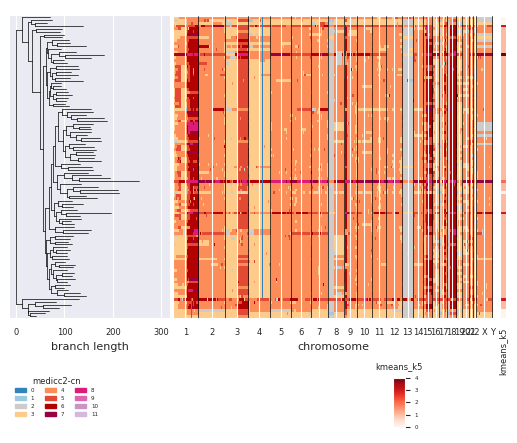

In [95]:
med_f1_score

In [ ]:
# g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name=None, tree=med_bio_tree, annotation_fields=[clustering_lab])
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='medicc2-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


### MEDICC2 tree on cellmates copy number profile

In [97]:
# plot cellmates cn onto medicc tree
medicc_adata_cells.layers['cellmates-cn'] = adata[cell_names, medicc_adata_cells.var_names].layers['cellmates-cn']
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='cellmates-cn', tree=med_bio_tree, annotation_fields=[clustering_lab])


MEDICC2 CN MAD against original (HMMcopy) 0.003940799789727997 - cellmates CN MAD agains original: 0.18787839509173296
MEDICC2 CN MAD against cellmates: 0.18802962483596686


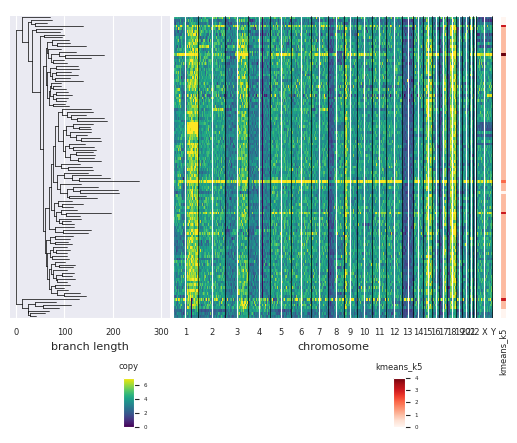

In [98]:
med_cn_mad = np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['state']))
print(f"MEDICC2 CN MAD against original (HMMcopy) {med_cn_mad} - cellmates CN MAD agains original: {cm_cn_mad}")
print(f"MEDICC2 CN MAD against cellmates: {np.nanmean(np.abs(medicc_adata_cells[cell_names, adata.var_names].layers['medicc2-cn'] - adata[cell_names].layers['cellmates-cn']))}")

In [99]:
perc_98 = np.nanquantile(medicc_adata_cells.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='copy', tree=med_bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

0.970873786407767

In [ ]:
# compare trees with RF
normalized_rf_distance(dpy_tree, med_dpy_tree)

## Analyse branch lengths

In [ ]:
from cellmates.utils.math_utils import compute_cn_changes
import seaborn as sns
from scipy.stats import pearsonr

def get_cells_branch_lengths(tree_nwk, cell_names):
    # traverse the tree and sum lengths over branches
    nx_tree = newick_to_nx(tree_nwk)
    root = [n for n,d in nx_tree.in_degree() if d==0][0]
    cell_lengths = []
    for c in cell_names:
        cell_lengths.append(nx.shortest_path_length(nx_tree, root, c, weight='weight'))

    return cell_lengths

def get_cells_cn_changes(cn_mat, cell_names, root_ploidy = 2):
    cell_cn_changes = []
    root_cn = np.zeros_like(cn_mat[0]) + root_ploidy
    for c in range(len(cell_names)):
        cell_cn_changes.append(compute_cn_changes(np.vstack((root_cn, cn_mat[c])))[0])
    return cell_cn_changes

def plot_xy(x, y, remove_outliers=False, x_cutoff=None):
    if x_cutoff is not None:
        x_new = []
        y_new = []
        for i, val in enumerate(x):
            if val < x_cutoff:
                x_new.append(val)
                y_new.append(y[i])
        x = x_new
        y = y_new

    corr, pval = pearsonr(x, y)
    print('pearson correlation:', corr)
    print('p-value:', pval)

    # Create plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red'})

    # Add correlation text
    plt.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.3e}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.xlabel('X values')
    plt.ylabel('Y values')

    # Set axes limits if outliers
    if remove_outliers:
        # Calculate percentiles to exclude outliers
        x_lower, x_upper = np.percentile(x, [2.5, 97.5])
        y_lower, y_upper = np.percentile(y, [2.5, 97.5])

        plt.xlim(x_lower, x_upper)
        plt.ylim(y_lower, y_upper)

    plt.title('Scatter Plot with Regression Line')
    plt.tight_layout()
    plt.show()

### Cellmates
Current analysis uses inference from CN data (fair comparison)

pearson correlation: 0.8551242199392698
p-value: 1.0248921177096426e-29


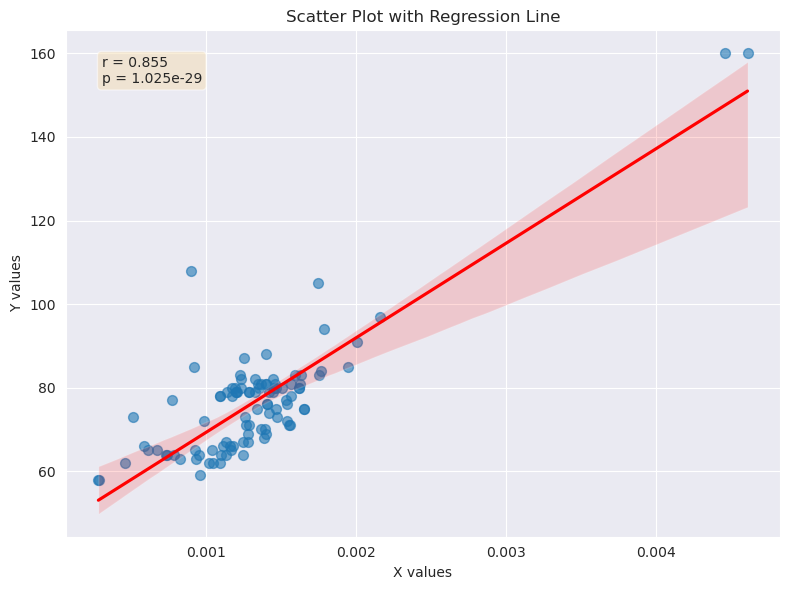

In [43]:
from math import log

cm_bl = get_cells_branch_lengths(tree_nwk, cell_names)
cm_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names) # CELLMATES CN 0.79 correlation
# cm_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.51
# cm_cc = get_cells_cn_changes(adata.layers['state'], cell_names) # HMMCopy 0.58
# log version
# cm_bl = [log(l+1) for l in cm_bl]  # 0.20 correlation


In [ ]:
plot_xy(cm_bl, cm_cc)
# plot_xy(cm_bl, cm_cc, x_cutoff=log(1.025))

### MEDICC2

pearson correlation: 0.8346000530627293
p-value: 1.9868201838570064e-28


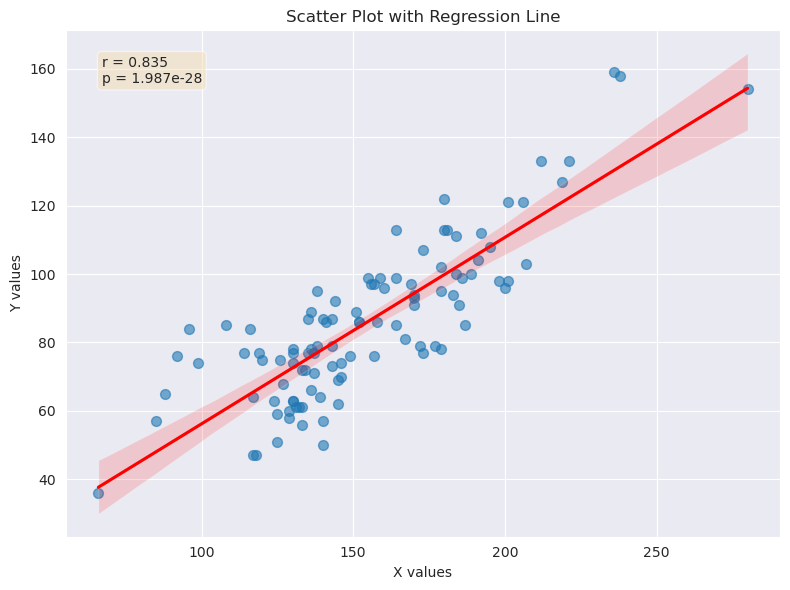

In [104]:
# for each cell
med_bl = get_cells_branch_lengths(med_tree_nwk, cell_names)
med_cc = get_cells_cn_changes(medicc_adata_cells.layers['medicc2-cn'], cell_names)  # MEDICC CN 0.83 pearson correlation
# med_cc = get_cells_cn_changes(adata.layers['cellmates-cn'], cell_names)  # CELLMATES CN 0.44
# med_cc = get_cells_cn_changes(adata.layers['state'], cell_names)  # HMMCopy 0.68



In [ ]:
plot_xy(med_bl, med_cc)

## The birthday problem
With many cells it is more likely that two unrelated cells share the same breakpoint. For each breakpoint detected in cellmates, we count the number of cells that exhibit that breakpoint
Cellmates shows less cells that carry unique breakpoints. However from cellmates cn plot it seems that CN breakpoints easily happen multiple times (back and forth) on the same bin.

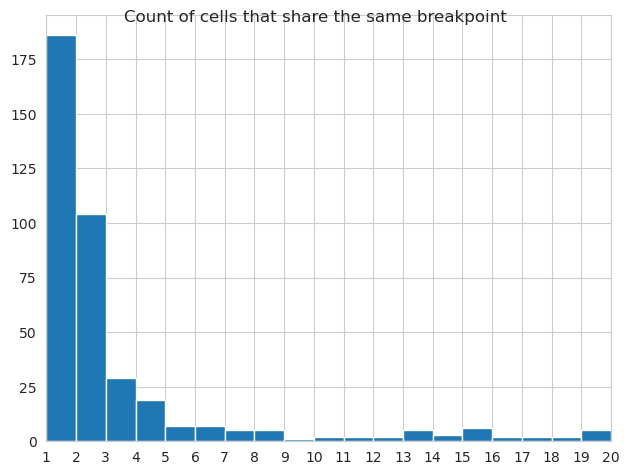

(array([186., 104.,  29.,  19.,   7.,   7.,   5.,   5.,   1.,   2.,   2.,
          2.,   5.,   3.,   6.,   2.,   2.,   2.,   5.,   0.,   2.,   1.,
          1.,   0.,   1.,   2.,   2.,   0.,   1.,   2.,   0.,   1.,   0.,
          1.,   0.,   0.,   1.,   1.,   0.,   2.,   2.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.,   1.,   1.,   0.,   0.,   0.,
          1.,   2.,   1.,   2.,   2.,   1.,   0.,   2.,   2.,   0.,   3.,
          0.,   0.,   3.,   1.,   1.,   2.,   2.,   0.,   1.,   0.,   1.,
          1.,   1.,   0.,   1.,   1.,   2.,   1.,   2.,   1.,   3.,   1.,
          1.,   2.,   1.,   0.,   2.,   3.,   1.,   4.,   1.,   5.,   8.]),
 array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
         45.,  46.,  47.,  48.,  49.

In [50]:
def cells_per_bkpt_shared_hist_single(cn_mat, title='Count of cells that share the same breakpoint', include_zero_count: bool = False):
    bkpt = np.diff(cn_mat, axis=1)
    # number of cells sharing the same breakpoint (for every breakpoint)
    binwidth = 1
    cells_per_bkpt = np.sum(bkpt != 0, axis=0)
    xstart = 0
    if not include_zero_count:
        xstart = 1
        cells_per_bkpt = cells_per_bkpt[cells_per_bkpt > 0]
    hist_dat = plt.hist(cells_per_bkpt, bins=range(xstart, max(cells_per_bkpt) + binwidth, binwidth))
    plt.xlim(xstart,20)
    plt.xticks(np.arange(xstart, 21, 1))
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()
    return hist_dat

def cells_per_bkpt_shared_hist(
    cn_mat,
    title='Count of cells that share the same breakpoint',
    include_zero_count: bool = False,
    labels=None,
    colors=None,
    figsize=(10, 6),
    style='whitegrid'
):
    """
    Plot histogram of cells sharing breakpoints with Seaborn styling.

    Parameters:
    -----------
    cn_mat : np.ndarray or list of np.ndarray
        Copy number matrix or list of matrices to plot
    title : str
        Plot title
    include_zero_count : bool
        Whether to include breakpoints with zero cells
    labels : list of str, optional
        Labels for each matrix (when passing list of matrices)
    colors : list of str, optional
        Colors for each histogram (when passing list of matrices)
    figsize : tuple
        Figure size (width, height)
    style : str
        Seaborn style ('whitegrid', 'darkgrid', 'white', 'dark', 'ticks')

    Returns:
    --------
    dict : Dictionary containing histogram data for each matrix
    """
    # Set seaborn style
    sns.set_style(style)

    # Handle single matrix or list of matrices
    if cn_mat.ndim == 3:
        cn_mat = [cn_mat[i] for i in range(cn_mat.shape[0])]

    if labels is None:
        labels = [f'Matrix {i+1}' for i in range(len(cn_mat))]

    if colors is None:
        colors = sns.color_palette('husl', len(cn_mat))

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    hist_data = {}
    all_cells_per_bkpt = []

    # Process each matrix
    for idx, mat in enumerate(cn_mat):
        bkpt = np.diff(mat, axis=1)
        cells_per_bkpt = np.sum(bkpt != 0, axis=0)

        xstart = 0 if include_zero_count else 1
        if not include_zero_count:
            cells_per_bkpt = cells_per_bkpt[cells_per_bkpt > 0]

        all_cells_per_bkpt.append(cells_per_bkpt)

        # Plot histogram with seaborn
        sns.histplot(
            cells_per_bkpt,
            bins=range(xstart, max(cells_per_bkpt) + 2),
            alpha=0.6,
            color=colors[idx],
            label=labels[idx],
            kde=False,
            ax=ax,
            stat='count'
        )

        hist_data[labels[idx]] = cells_per_bkpt

    # Styling
    ax.set_xlim(xstart if include_zero_count else 1, 20)
    ax.set_xticks(np.arange(xstart if include_zero_count else 1, 21, 1))
    ax.set_xlabel('Number of cells sharing breakpoint', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    if len(cn_mat) > 1:
        ax.legend(frameon=True, shadow=True, fontsize=10)

    # Add grid for better readability
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return hist_data


<Axes: title={'center': 'Copy number profile'}, xlabel='bins', ylabel='cells'>

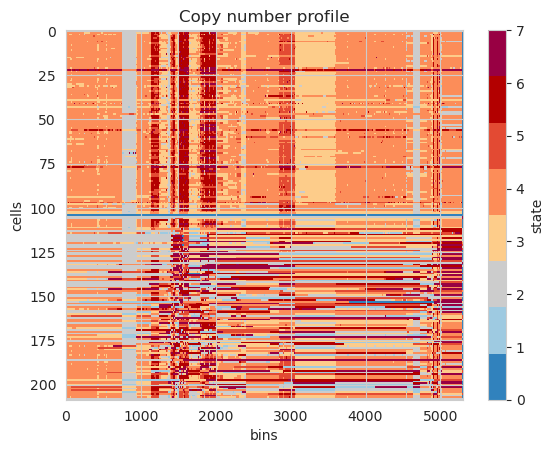

In [147]:
# cells_per_bkpt_shared_hist(adata.layers['cellmates-cn'], labels=['cellmates'], title='Count of cells that share the same breakpoint', include_zero_count=True)
cells_per_bkpt_shared_hist_single(adata.layers['cellmates-cn'], title='Count of cells that share the same breakpoint', include_zero_count=False)

In [ ]:
from cellmates.utils.visual import plot_cn_profile
full_cn_pred = np.load(os.path.join(cm_out_dir, 'predicted_copy_numbers.npz'))
plot_cn_profile(full_cn_pred['data'])